In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [363]:
df = pd.read_csv("Boston.csv")

In [364]:
display(df.head())

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [365]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0',axis = 1)

In [366]:
print("Shape:",df.shape)
print("Columns:",df.columns)

Shape: (506, 14)
Columns: Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')


In [367]:
print(df.dtypes)

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object


In [368]:
display(df.describe())


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [369]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


In [370]:
print(df.duplicated().sum())

0


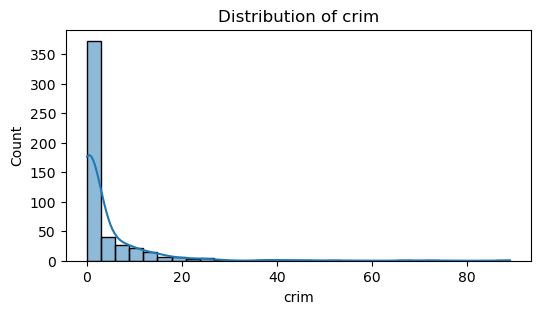

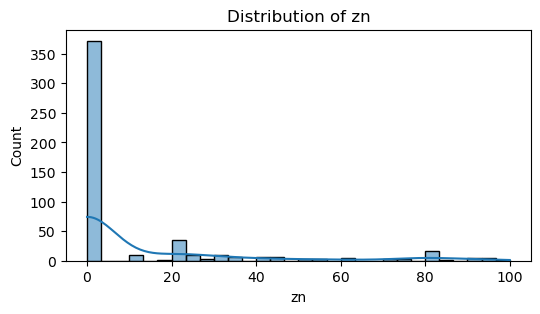

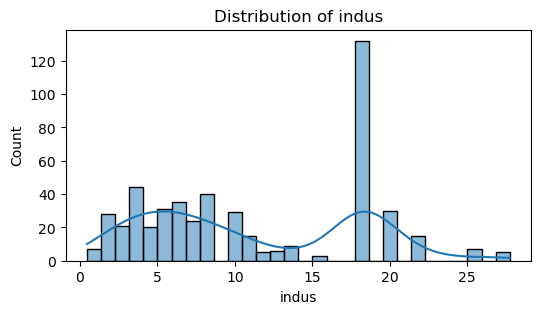

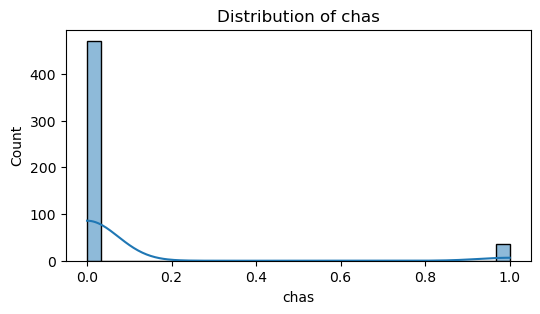

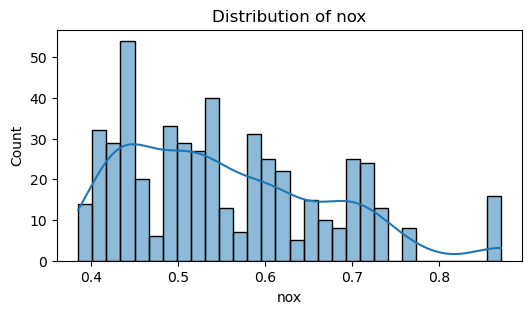

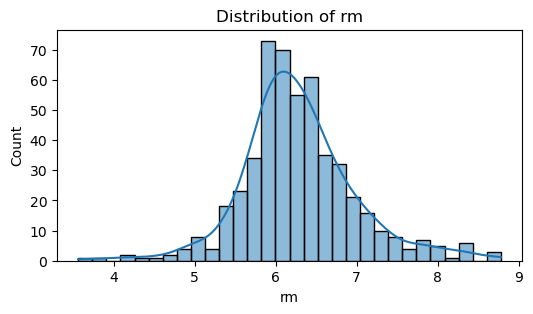

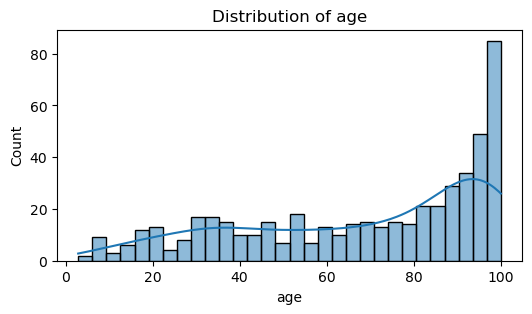

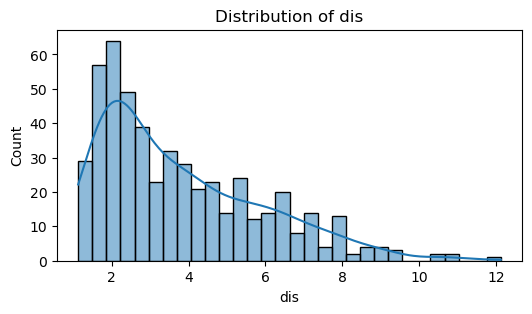

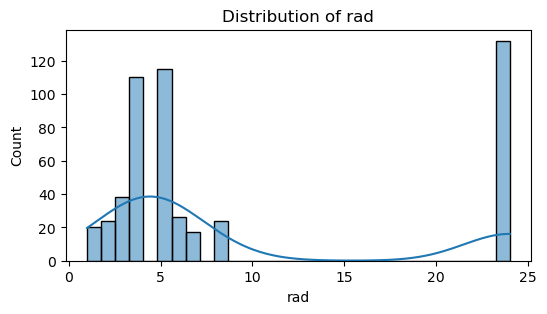

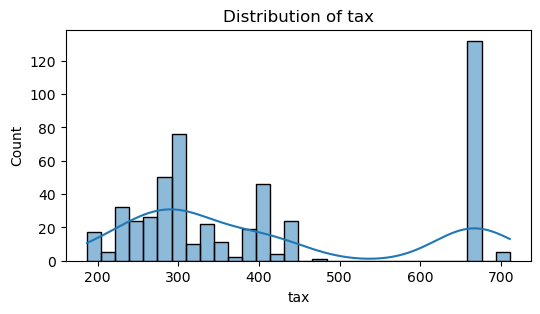

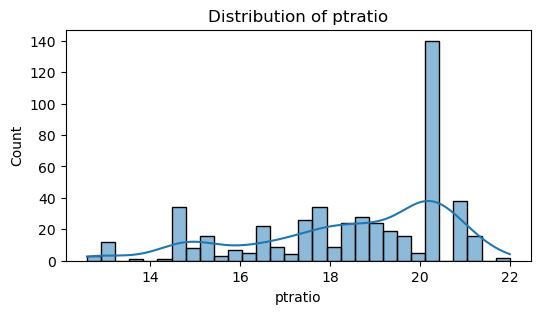

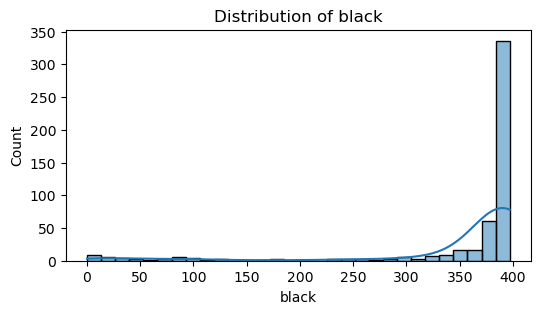

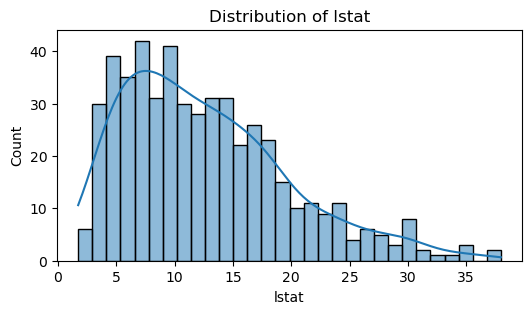

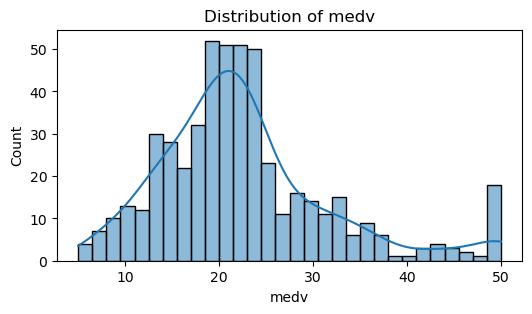

In [371]:
cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col],kde = True,bins = 30)
    plt.title(f'Distribution of {col}')
    plt.show()

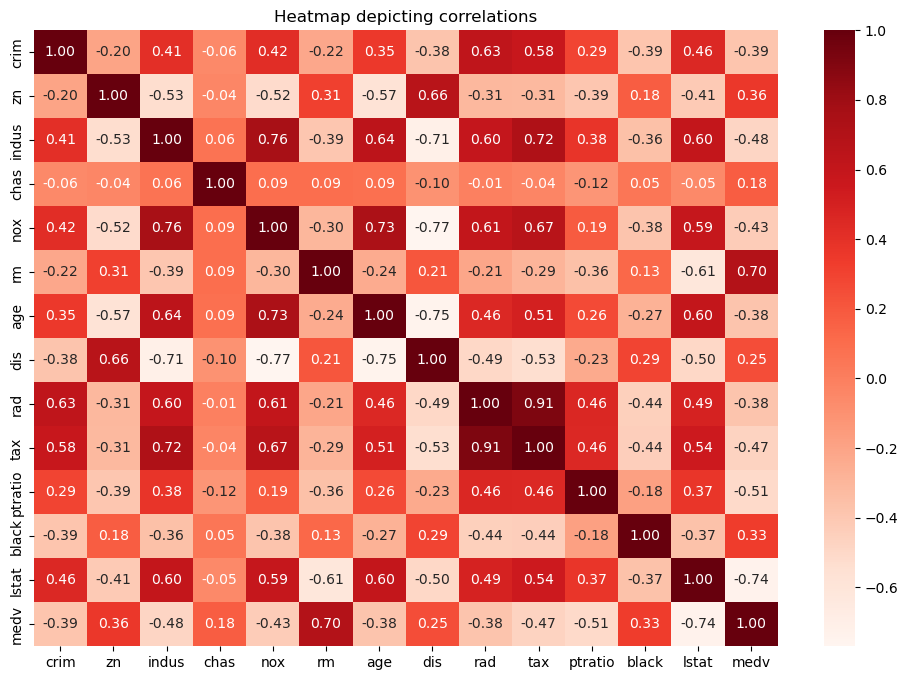

In [372]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr,annot = True,fmt = ".2f",cmap = 'Reds')
plt.title("Heatmap depicting correlations")
plt.show()

In [373]:
X = df.drop(['medv','zn'],axis = 1)
y = df['medv'].values

In [374]:
X['rm_Sq'] = X['rm']**3
X['lstat_cub'] = X['lstat']**2
X['rm_lstat'] = X['rm'] * X['lstat']
X['age_rm'] = X['age'] * X['rm']
#X['dis_nox'] = X['dis'] * X['nox']
#X['tax_pt'] = X['tax'] * X['ptratio']
X['tax_per_rm'] = X['tax']/X['rm']
#X['lstat_per_rm'] = X['lstat']/X['rm']

In [375]:
m = X.shape[0]
#train_size = int(0.8*m)
#X_train = X[:train_size]
#y_train = y[:train_size]
#X_test = X[train_size:]
#y_test = y[train_size:]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [399]:
X_train_scaled = ((X_train-X_train.mean())/X_train.std()).values
X_test_scaled = ((X_test-X_train.mean())/X_train.std()).values

In [400]:
b = 0
alpha
iterations
ridge_lda 
w = np.zeros(X_train_scaled.shape[1])
m_train = len(y_train)

In [401]:
def calculate_cost(x,y,w,b,ridge_lda):
    y_pred = x.dot(w)+b
    mse = (1/(2*len(y)))*np.sum((y_pred - y)**2)
    reg = (ridge_lda/(2*len(y)))*np.sum(w**2)
    return mse+reg

In [402]:
def grad_descent(X_train_scaled,y_train,alpha,ridge_lda,iterations):
    m_train = len(y_train)
    w = np.zeros(X_train_scaled.shape[1])
    b = 0
    Costs = []
    for i in range(iterations):
        y_pred = b + X_train_scaled.dot(w)
        e = y_pred - y_train
        b_temp = (1/m_train) * np.sum(e)
        w_temp = (1/m_train) * (X_train_scaled.T.dot(e))+(ridge_lda*w)
        b = b-alpha*b_temp
        w = w-alpha*w_temp
        cost=calculate_cost(X_train_scaled,y_train,w,b,ridge_lda)
        Costs.append(cost)
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    print("Weights:", w)
    print("Bias:", b)
    return w,b,Costs

In [403]:
w_ridge,b_ridge,Costs_ridge = grad_descent(X_train_scaled,y_train,alpha=0.1,ridge_lda=0.01,iterations=12000)
print("Final cost:", calculate_cost(X_train_scaled,y_train,w_ridge,b_ridge,ridge_lda))

Iteration 0: Cost = 230.3938
Iteration 1000: Cost = 7.8143
Iteration 2000: Cost = 7.8027
Iteration 3000: Cost = 7.8003
Iteration 4000: Cost = 7.7997
Iteration 5000: Cost = 7.7995
Iteration 6000: Cost = 7.7994
Iteration 7000: Cost = 7.7994
Iteration 8000: Cost = 7.7994
Iteration 9000: Cost = 7.7994
Iteration 10000: Cost = 7.7994
Iteration 11000: Cost = 7.7994
Weights: [-1.17480594  0.33107188  0.6256386  -1.74090886  0.25439345  1.43016655
 -2.11535877  1.6642568  -3.30301426 -1.6376154   0.70551312 -2.24832796
  4.60506661  3.01275005 -4.50850758 -1.36922231  2.44860259]
Bias: 22.79653465346533
Final cost: 7.799418033124889


In [404]:
y_test_pred = X_test_scaled.dot(w_ridge)+b_ridge

In [405]:
mse = np.mean((y_test-y_test_pred)**2)
print("MSE:",mse)

MSE: 14.442151884682561


In [406]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 3.8002831321735173


In [407]:
mae = np.mean(np.abs(y_test-y_test_pred))
print("MAE:",mae)

MAE: 2.447356978184022


In [408]:
R2 = 1 - (np.sum((y_test - y_test_pred)**2) / np.sum((y_test - np.mean(y_test))**2))
print(R2)

0.8030627732226905


Using huber loss as loss function:

In [409]:
def huber_loss(y_true,y_pred,delta=1):
    error = y_pred-y_true
    small_error = np.abs(error)<=delta
    squared_loss = 0.5*(error**2)
    linear_loss=delta*(np.abs(error)-0.5*delta)
    return np.where(small_error,squared_loss,linear_loss)

In [410]:
def huber_loss_descent(X_train_scaled,y_train,alpha,ridge_lambda,delta,iterations):
    m_train = len(y_train)
    w = np.zeros(X_train_scaled.shape[1])
    b = 0
    costs = []
    for i in range(iterations):
        y_pred = b + X_train_scaled.dot(w)
        error = y_pred - y_train
        cdn = np.abs(error)<=delta
        error_in_grad = np.where(cdn,error,delta*np.sign(error))
        b_temp = (1/m_train) * np.sum(error_in_grad)
        w_temp = (1/m_train) * X_train_scaled.T.dot(error_in_grad)+ridge_lambda*w
        b = b-alpha*b_temp
        w = w-alpha*w_temp
        cost = np.mean(huber_loss(y_train,y_pred,delta))+(ridge_lambda/2)*np.sum(w**2)
        costs.append(cost)
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
        
    print("Weights:", w)
    print("Bias:", b)
    return w,b,costs

In [418]:
w_huber,b_huber,costs = huber_loss_descent(X_train_scaled,y_train,alpha=0.01,ridge_lambda=0.001,delta=18.0,iterations=20000)
y_test_huber = X_test_scaled.dot(w_huber)+b_huber
r2_huber = 1 - (np.sum((y_test - y_test_huber)**2) / np.sum((y_test - np.mean(y_test))**2))
print("R2 score:",r2_huber)

Iteration 0: Cost = 252.8546
Iteration 1000: Cost = 8.4243
Iteration 2000: Cost = 7.9030
Iteration 3000: Cost = 7.7694
Iteration 4000: Cost = 7.7262
Iteration 5000: Cost = 7.7080
Iteration 6000: Cost = 7.6979
Iteration 7000: Cost = 7.6913
Iteration 8000: Cost = 7.6864
Iteration 9000: Cost = 7.6827
Iteration 10000: Cost = 7.6798
Iteration 11000: Cost = 7.6775
Iteration 12000: Cost = 7.6755
Iteration 13000: Cost = 7.6739
Iteration 14000: Cost = 7.6726
Iteration 15000: Cost = 7.6714
Iteration 16000: Cost = 7.6704
Iteration 17000: Cost = 7.6694
Iteration 18000: Cost = 7.6686
Iteration 19000: Cost = 7.6678
Weights: [-1.22878907  0.49044972  0.59829654 -1.74936292 -0.29447344  1.93003295
 -2.04887779  1.86953807 -4.04733508 -1.58877569  0.67181077 -1.92576363
  5.63321583  2.97301332 -4.70581714 -1.91082214  2.94047883]
Bias: 22.78316495075938
R2 score: 0.8102365669231998


In [419]:
mse = np.mean((y_test-y_test_huber)**2)
print("MSE:",mse)

MSE: 13.916070453012523


In [420]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 3.73042496949242


In [421]:
mae = np.mean(np.abs(y_test-y_test_huber))
print("MAE:",mae)

MAE: 2.3732960085539396
